In [16]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
os.listdir('/content/drive/My Drive')

['amr-guardian',
 'Dl Models',
 'DriveSharer',
 'Kolop',
 'GDToT',
 'me.jpg',
 'WhatsApp Image 2024-12-20 at 22.40.37_fcdc2f8a.jpg',
 'Colab Notebooks',
 'WhatsApp Image 2025-02-08 at 20.49.09_02e7cb53.jpg',
 'Copy of VC_RedistInstaller.exe',
 'To-do list.gsheet',
 'Google sheets',
 'Untitled spreadsheet.gsheet',
 'changed data type(numeric) (2).xlsx',
 'changed data type(numeric) (1).xlsx',
 'changed data type(numeric).xlsx',
 'changed data type(numeric).gsheet',
 'df_78_data.xlsx',
 'pratice sheet.gsheet',
 'Ask Gemini about the role of pyhton in plant bree... (5).gdoc',
 'Ask Gemini about the role of pyhton in plant bree... (4).gdoc',
 'Ask Gemini about the role of pyhton in plant bree... (3).gdoc',
 'Ask Gemini about the role of pyhton in plant bree... (2).gdoc',
 'Ask Gemini about the role of pyhton in plant bree... (1).gdoc',
 'Ask Gemini about the role of pyhton in plant bree....gdoc',
 'Emails to different stakeholders.gdoc',
 'mmem.jpg',
 'Tableau',
 'Learner-facing C3 Automat

In [20]:
import os
os.listdir('/content/drive/My Drive/amr-guardian')

['Untitled0.ipynb']

In [21]:
dir = '/content/drive/My Drive/amr-guardian'

In [22]:
!pip install groq

In [23]:
from google.colab import userdata
from groq import Groq

client = Groq(api_key=userdata.get('GROQ_API_KEY'))

In [28]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/amr_guardian/parsers', exist_ok=True)
print("Folders created!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders created!


In [29]:
%%writefile /content/drive/MyDrive/amr_guardian/parsers/groq_parser.py

# amr_guardian/parsers/groq_parser.py

import json
import re
import logging
from typing import Any
from dataclasses import dataclass, field

logger = logging.getLogger(__name__)


# ─────────────────────────────────────────────
# Data Models
# ─────────────────────────────────────────────

@dataclass
class ResistanceProfile:
    pathogen: str
    antibiotic: str
    resistance_level: str          # RESISTANT / INTERMEDIATE / SUSCEPTIBLE
    mic_value: str | None = None   # Minimum Inhibitory Concentration
    confidence_score: float = 0.0  # 0.0 – 1.0
    evidence_basis: str = ""
    alternative_antibiotics: list[str] = field(default_factory=list)
    notes: str = ""


@dataclass
class AMRParseResult:
    raw_response: str
    resistance_profiles: list[ResistanceProfile] = field(default_factory=list)
    risk_level: str = "UNKNOWN"         # LOW / MEDIUM / HIGH / CRITICAL
    recommended_actions: list[str] = field(default_factory=list)
    treatment_guidelines: list[str] = field(default_factory=list)
    warnings: list[str] = field(default_factory=list)
    parse_errors: list[str] = field(default_factory=list)
    metadata: dict[str, Any] = field(default_factory=dict)


# ─────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────

RESISTANCE_LEVELS = {"RESISTANT", "INTERMEDIATE", "SUSCEPTIBLE", "R", "I", "S"}

RESISTANCE_LEVEL_MAP = {
    "R": "RESISTANT",
    "I": "INTERMEDIATE",
    "S": "SUSCEPTIBLE",
    "RESISTANT": "RESISTANT",
    "INTERMEDIATE": "INTERMEDIATE",
    "SUSCEPTIBLE": "SUSCEPTIBLE",
}

RISK_LEVELS = {"LOW", "MEDIUM", "HIGH", "CRITICAL"}

VALID_RISK_KEYWORDS = {
    "critical": "CRITICAL",
    "high": "HIGH",
    "medium": "MEDIUM",
    "moderate": "MEDIUM",
    "low": "LOW",
}

COMMON_PATHOGENS = {
    "e. coli", "escherichia coli", "staphylococcus aureus", "mrsa",
    "klebsiella pneumoniae", "acinetobacter baumannii", "pseudomonas aeruginosa",
    "enterococcus faecium", "streptococcus pneumoniae", "salmonella",
}

COMMON_ANTIBIOTICS = {
    "amoxicillin", "ampicillin", "azithromycin", "cefazolin", "ceftriaxone",
    "ciprofloxacin", "clindamycin", "doxycycline", "erythromycin", "gentamicin",
    "levofloxacin", "linezolid", "meropenem", "metronidazole", "oxacillin",
    "penicillin", "piperacillin", "rifampin", "tetracycline", "trimethoprim",
    "vancomycin",
}


# ─────────────────────────────────────────────
# Core Parser
# ─────────────────────────────────────────────

class GroqAMRParser:
    """
    Parses Groq LLM responses for AMR Guardian.
    Handles JSON-structured responses, semi-structured text,
    and falls back to regex extraction when needed.
    """

    def __init__(self, strict_mode: bool = False):
        """
        Args:
            strict_mode: If True, raises ValueError on unrecognised pathogens
                         or antibiotics. If False, logs a warning and continues.
        """
        self.strict_mode = strict_mode

    # ── Public entry point ──────────────────────────────────────────────────

    def parse(self, groq_response: str | dict) -> AMRParseResult:
        """
        Main parser entry point.

        Accepts:
          - A raw string (Groq API message content)
          - A dict (already-decoded Groq API response object)

        Returns:
          AMRParseResult with all extracted data.
        """
        raw_text = self._extract_text(groq_response)
        result = AMRParseResult(raw_response=raw_text)

        try:
            json_data = self._try_extract_json(raw_text)
            if json_data:
                self._parse_json_response(json_data, result)
            else:
                self._parse_text_response(raw_text, result)
        except Exception as exc:
            logger.exception("Unexpected error during AMR parsing")
            result.parse_errors.append(f"Fatal parse error: {exc}")

        self._validate_result(result)
        return result

    # ── Text extraction ──────────────────────────────────────────────────────

    def _extract_text(self, response: str | dict) -> str:
        if isinstance(response, str):
            return response.strip()
        if isinstance(response, dict):
            # Standard Groq / OpenAI-compatible response shape
            try:
                return response["choices"][0]["message"]["content"].strip()
            except (KeyError, IndexError, TypeError):
                pass
            # Flat dict with a 'content' key
            if "content" in response:
                return str(response["content"]).strip()
        raise ValueError(f"Unsupported response type: {type(response)}")

    # ── JSON extraction ──────────────────────────────────────────────────────

    def _try_extract_json(self, text: str) -> dict | list | None:
        """
        Try to extract a JSON block from the text.
        Handles ```json ... ``` fences and bare JSON objects/arrays.
        """
        # Fenced code block
        fence_match = re.search(
            r"```(?:json)?\s*(\{[\s\S]*?\}|\[[\s\S]*?\])\s*```",
            text,
            re.IGNORECASE,
        )
        if fence_match:
            try:
                return json.loads(fence_match.group(1))
            except json.JSONDecodeError:
                pass

        # Bare JSON object
        obj_match = re.search(r"\{[\s\S]*\}", text)
        if obj_match:
            try:
                return json.loads(obj_match.group())
            except json.JSONDecodeError:
                pass

        return None

    # ── JSON-path parsing ────────────────────────────────────────────────────

    def _parse_json_response(self, data: dict | list, result: AMRParseResult) -> None:
        if isinstance(data, list):
            for item in data:
                self._parse_single_profile(item, result)
            return

        # Top-level resistance profiles
        profiles_raw = (
            data.get("resistance_profiles")
            or data.get("resistanceProfiles")
            or data.get("profiles")
            or (data.get("pathogen") and [data])   # single-profile response
            or []
        )
        for profile_data in profiles_raw:
            self._parse_single_profile(profile_data, result)

        # Risk level
        risk_raw = (
            data.get("risk_level")
            or data.get("riskLevel")
            or data.get("overall_risk")
            or ""
        )
        result.risk_level = self._normalise_risk(risk_raw)

        # Lists
        result.recommended_actions = self._coerce_list(
            data.get("recommended_actions") or data.get("recommendedActions") or []
        )
        result.treatment_guidelines = self._coerce_list(
            data.get("treatment_guidelines") or data.get("treatmentGuidelines") or []
        )
        result.warnings = self._coerce_list(
            data.get("warnings") or []
        )
        result.metadata = data.get("metadata") or {}

    def _parse_single_profile(self, data: dict, result: AMRParseResult) -> None:
        try:
            pathogen = str(
                data.get("pathogen") or data.get("organism") or data.get("bacteria") or ""
            ).strip()
            antibiotic = str(
                data.get("antibiotic") or data.get("drug") or data.get("antimicrobial") or ""
            ).strip()

            if not pathogen or not antibiotic:
                result.parse_errors.append(
                    f"Incomplete profile (missing pathogen or antibiotic): {data}"
                )
                return

            resistance_raw = str(
                data.get("resistance_level")
                or data.get("resistanceLevel")
                or data.get("susceptibility")
                or data.get("result")
                or ""
            ).strip().upper()

            resistance_level = RESISTANCE_LEVEL_MAP.get(resistance_raw, "UNKNOWN")
            if resistance_level == "UNKNOWN":
                result.parse_errors.append(
                    f"Unrecognised resistance level '{resistance_raw}' for {pathogen}/{antibiotic}"
                )

            confidence = self._parse_float(
                data.get("confidence_score") or data.get("confidence") or 0.0
            )

            profile = ResistanceProfile(
                pathogen=self._validate_pathogen(pathogen, result),
                antibiotic=self._validate_antibiotic(antibiotic, result),
                resistance_level=resistance_level,
                mic_value=data.get("mic_value") or data.get("mic") or None,
                confidence_score=min(max(confidence, 0.0), 1.0),
                evidence_basis=str(data.get("evidence_basis") or data.get("evidence") or ""),
                alternative_antibiotics=self._coerce_list(
                    data.get("alternative_antibiotics")
                    or data.get("alternatives")
                    or []
                ),
                notes=str(data.get("notes") or ""),
            )
            result.resistance_profiles.append(profile)

        except Exception as exc:
            result.parse_errors.append(f"Profile parse error: {exc} — raw: {data}")

    # ── Plain-text fallback parser ────────────────────────────────────────────

    def _parse_text_response(self, text: str, result: AMRParseResult) -> None:
        """
        Regex-based extraction when the LLM response is not JSON.
        """
        # Risk level
        for keyword, level in VALID_RISK_KEYWORDS.items():
            if re.search(rf"\b{keyword}\b", text, re.IGNORECASE):
                result.risk_level = level
                break

        # Resistance statements, e.g.:
        #   "E. coli is RESISTANT to ciprofloxacin"
        #   "Klebsiella: vancomycin – R"
        resistance_pattern = re.compile(
            r"([A-Za-z][A-Za-z\s\.\-]+?)\s+"          # pathogen
            r"(?:is\s+|:\s*|–\s*)?"                    # optional connector
            r"(RESISTANT|INTERMEDIATE|SUSCEPTIBLE|[RIS])\b"  # level
            r"(?:\s+to\s+([A-Za-z][A-Za-z\s\-]+?))?", # optional antibiotic
            re.IGNORECASE,
        )
        for m in resistance_pattern.finditer(text):
            pathogen_candidate = m.group(1).strip()
            level_raw = m.group(2).strip().upper()
            antibiotic_candidate = (m.group(3) or "unknown").strip()

            level = RESISTANCE_LEVEL_MAP.get(level_raw, "UNKNOWN")
            if any(p in pathogen_candidate.lower() for p in COMMON_PATHOGENS):
                result.resistance_profiles.append(
                    ResistanceProfile(
                        pathogen=pathogen_candidate,
                        antibiotic=antibiotic_candidate,
                        resistance_level=level,
                        confidence_score=0.5,   # lower confidence for regex path
                        notes="Extracted via regex fallback",
                    )
                )

        # Recommended actions — lines starting with a bullet/number
        action_pattern = re.compile(r"^[\-\*\d\.\)]+\s+(.+)$", re.MULTILINE)
        for m in action_pattern.finditer(text):
            action = m.group(1).strip()
            if len(action) > 10:
                result.recommended_actions.append(action)

        # Warnings
        warning_pattern = re.compile(
            r"(?:warning|caution|alert|note)[:\s]+(.+?)(?:\.|$)",
            re.IGNORECASE | re.MULTILINE,
        )
        for m in warning_pattern.finditer(text):
            result.warnings.append(m.group(1).strip())

        if not result.resistance_profiles:
            result.parse_errors.append(
                "No structured resistance data found; regex fallback also yielded nothing."
            )

    # ── Validation helpers ────────────────────────────────────────────────────

    def _validate_result(self, result: AMRParseResult) -> None:
        if not result.resistance_profiles:
            result.warnings.append("No resistance profiles were extracted.")

        if result.risk_level == "UNKNOWN" and result.resistance_profiles:
            result.risk_level = self._infer_risk_from_profiles(result.resistance_profiles)

    def _infer_risk_from_profiles(self, profiles: list[ResistanceProfile]) -> str:
        resistant_count = sum(
            1 for p in profiles if p.resistance_level == "RESISTANT"
        )
        if resistant_count == 0:
            return "LOW"
        if resistant_count <= 2:
            return "MEDIUM"
        if resistant_count <= 4:
            return "HIGH"
        return "CRITICAL"

    def _validate_pathogen(self, name: str, result: AMRParseResult) -> str:
        if name.lower() not in COMMON_PATHOGENS:
            msg = f"Unrecognised pathogen: '{name}'"
            if self.strict_mode:
                raise ValueError(msg)
            logger.warning(msg)
            result.warnings.append(msg)
        return name

    def _validate_antibiotic(self, name: str, result: AMRParseResult) -> str:
        if name.lower() not in COMMON_ANTIBIOTICS:
            msg = f"Unrecognised antibiotic: '{name}'"
            if self.strict_mode:
                raise ValueError(msg)
            logger.warning(msg)
            result.warnings.append(msg)
        return name

    # ── Utility helpers ───────────────────────────────────────────────────────

    @staticmethod
    def _normalise_risk(raw: str) -> str:
        upper = raw.strip().upper()
        if upper in RISK_LEVELS:
            return upper
        for keyword, level in VALID_RISK_KEYWORDS.items():
            if keyword in raw.lower():
                return level
        return "UNKNOWN"

    @staticmethod
    def _coerce_list(value: Any) -> list[str]:
        if isinstance(value, list):
            return [str(v) for v in value]
        if isinstance(value, str) and value:
            return [value]
        return []

    @staticmethod
    def _parse_float(value: Any) -> float:
        try:
            return float(value)
        except (TypeError, ValueError):
            return 0.0


# ─────────────────────────────────────────────
# Convenience wrapper
# ─────────────────────────────────────────────

def parse_groq_amr_response(
    groq_response: str | dict,
    strict_mode: bool = False,
) -> AMRParseResult:
    """
    Top-level convenience function.

    Usage:
        result = parse_groq_amr_response(groq_api_response)
        for profile in result.resistance_profiles:
            print(profile.pathogen, profile.antibiotic, profile.resistance_level)
    """
    parser = GroqAMRParser(strict_mode=strict_mode)
    return parser.parse(groq_response)

Writing /content/drive/MyDrive/amr_guardian/parsers/groq_parser.py


In [30]:
%%writefile /content/drive/MyDrive/amr_guardian/__init__.py
# AMR Guardian

Writing /content/drive/MyDrive/amr_guardian/__init__.py


In [31]:
%%writefile /content/drive/MyDrive/amr_guardian/parsers/__init__.py
# Parsers

Writing /content/drive/MyDrive/amr_guardian/parsers/__init__.py


In [32]:
import sys
sys.path.insert(0, '/content/drive/MyDrive')

from amr_guardian.parsers.groq_parser import parse_groq_amr_response

fake_response = """{
  "resistance_profiles": [
    {"pathogen": "E. coli", "antibiotic": "ciprofloxacin", "resistance_level": "RESISTANT"},
    {"pathogen": "E. coli", "antibiotic": "gentamicin", "resistance_level": "SUSCEPTIBLE"}
  ],
  "risk_level": "HIGH"
}"""

result = parse_groq_amr_response(fake_response)
print("Risk Level:", result.risk_level)
for p in result.resistance_profiles:
    print(f"  {p.pathogen} | {p.antibiotic} | {p.resistance_level}")

Risk Level: HIGH
  E. coli | ciprofloxacin | RESISTANT
  E. coli | gentamicin | SUSCEPTIBLE


In [33]:
# Step 4: Generate 300-row synthetic AMR dataset
# Run this in Google Colab

import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

# ── Setup ──────────────────────────────────────────────────────────────────
np.random.seed(42)
save_path = '/content/drive/MyDrive/amr_guardian/data/'
os.makedirs(save_path, exist_ok=True)

# ── Define categories ──────────────────────────────────────────────────────
cities     = ['Karachi', 'Lahore', 'Islamabad', 'Peshawar', 'Quetta']
organisms  = ['E. coli', 'Klebsiella', 'MRSA', 'Pseudomonas',
              'Salmonella', 'Acinetobacter', 'Enterococcus', 'Streptococcus']
antibiotics = ['Ciprofloxacin', 'Amoxicillin', 'Gentamicin', 'Meropenem',
               'Vancomycin', 'Ceftriaxone', 'Azithromycin', 'Levofloxacin',
               'Ampicillin', 'Trimethoprim', 'Rifampin', 'Linezolid']

# ── Realistic resistance weights [Resistant, Intermediate, Susceptible] ────
# Based on Pakistani AMR surveillance data patterns
resistance_map = {
    ('E. coli',        'Ciprofloxacin'):  [0.75, 0.10, 0.15],
    ('E. coli',        'Amoxicillin'):    [0.80, 0.05, 0.15],
    ('E. coli',        'Ampicillin'):     [0.82, 0.05, 0.13],
    ('E. coli',        'Trimethoprim'):   [0.70, 0.08, 0.22],
    ('E. coli',        'Meropenem'):      [0.15, 0.10, 0.75],
    ('E. coli',        'Gentamicin'):     [0.45, 0.10, 0.45],
    ('Klebsiella',     'Ciprofloxacin'):  [0.65, 0.12, 0.23],
    ('Klebsiella',     'Meropenem'):      [0.30, 0.15, 0.55],
    ('Klebsiella',     'Ceftriaxone'):    [0.60, 0.10, 0.30],
    ('MRSA',           'Vancomycin'):     [0.05, 0.10, 0.85],
    ('MRSA',           'Linezolid'):      [0.03, 0.05, 0.92],
    ('MRSA',           'Rifampin'):       [0.20, 0.10, 0.70],
    ('Pseudomonas',    'Meropenem'):      [0.35, 0.15, 0.50],
    ('Pseudomonas',    'Ciprofloxacin'):  [0.55, 0.12, 0.33],
    ('Acinetobacter',  'Meropenem'):      [0.70, 0.10, 0.20],
    ('Acinetobacter',  'Ciprofloxacin'):  [0.80, 0.08, 0.12],
    ('Salmonella',     'Ciprofloxacin'):  [0.40, 0.15, 0.45],
    ('Salmonella',     'Azithromycin'):   [0.30, 0.20, 0.50],
    ('Enterococcus',   'Vancomycin'):     [0.15, 0.08, 0.77],
    ('Enterococcus',   'Linezolid'):      [0.05, 0.05, 0.90],
    ('Streptococcus',  'Ampicillin'):     [0.20, 0.10, 0.70],
    ('Streptococcus',  'Azithromycin'):   [0.45, 0.15, 0.40],
}
default_weights = [0.35, 0.15, 0.50]  # fallback for unlisted combos

# ── Generate random dates in 2024 ──────────────────────────────────────────
start = datetime(2024, 1, 1)
dates = [start + timedelta(days=int(d)) for d in np.random.randint(0, 366, 300)]

# ── Build rows ─────────────────────────────────────────────────────────────
rows = []
for i in range(300):
    city       = np.random.choice(cities)
    organism   = np.random.choice(organisms)
    antibiotic = np.random.choice(antibiotics)
    weights    = resistance_map.get((organism, antibiotic), default_weights)
    result     = np.random.choice(['Resistant', 'Intermediate', 'Susceptible'], p=weights)
    rows.append({
        'city':       city,
        'organism':   organism,
        'antibiotic': antibiotic,
        'result':     result,
        'date':       dates[i].strftime('%Y-%m-%d')
    })

# ── Save ───────────────────────────────────────────────────────────────────
df = pd.DataFrame(rows)
df.to_csv(save_path + 'amr_data.csv', index=False)

print("Saved to", save_path + 'amr_data.csv')
print(f"   Shape: {df.shape}")
print()
print(df.head())

Saved to /content/drive/MyDrive/amr_guardian/data/amr_data.csv
   Shape: (300, 5)

        city       organism     antibiotic       result        date
0    Karachi  Acinetobacter     Vancomycin    Resistant  2024-04-12
1  Islamabad        E. coli  Ciprofloxacin    Resistant  2024-12-14
2  Islamabad           MRSA    Ceftriaxone    Resistant  2024-09-27
3     Quetta           MRSA    Ceftriaxone  Susceptible  2024-04-16
4  Islamabad     Klebsiella     Vancomycin  Susceptible  2024-03-12


✅ Loaded: (300, 5)
        city       organism     antibiotic     result        date
0    Karachi  Acinetobacter     Vancomycin  Resistant  2024-04-12
1  Islamabad        E. coli  Ciprofloxacin  Resistant  2024-12-14
2  Islamabad           MRSA    Ceftriaxone  Resistant  2024-09-27

📊 GLOBAL ANTIBIOGRAM (% Resistant)
antibiotic     Amoxicillin  Ampicillin  Azithromycin  Ceftriaxone  \
organism                                                            
Acinetobacter         20.0        33.3           0.0          0.0   
E. coli               50.0         0.0          50.0         33.3   
Enterococcus          50.0        25.0           0.0          0.0   
Klebsiella            75.0         0.0          33.3         62.5   
MRSA                   0.0         0.0          75.0         50.0   
Pseudomonas          100.0        40.0           0.0          0.0   
Salmonella             0.0         0.0           0.0         25.0   
Streptococcus          0.0         0.0          75.0        

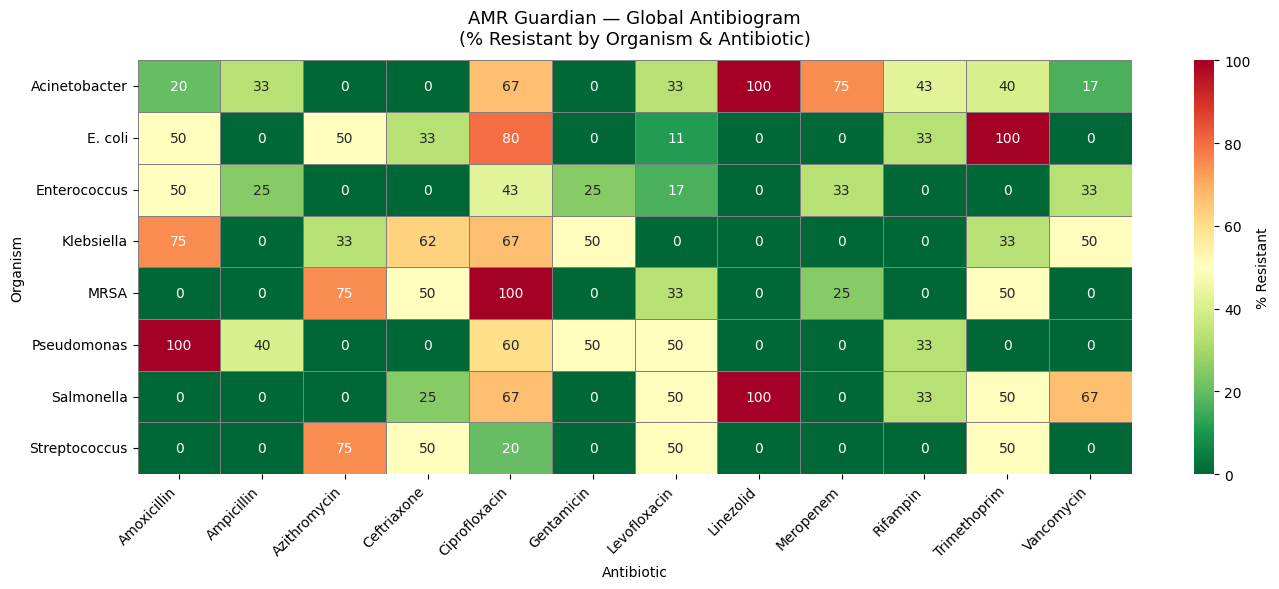

✅ Saved: antibiogram_heatmap.png


In [34]:
# Step 5: Antibiogram Pipeline
# Reads amr_data.csv and computes resistance tables

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Load CSV ───────────────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/amr_guardian/data/amr_data.csv')
print("✅ Loaded:", df.shape)
print(df.head(3))

# ── Helper: % Resistant function ───────────────────────────────────────────
def percent_resistant(series):
    return round((series == 'Resistant').sum() / len(series) * 100, 1)

# ══════════════════════════════════════════════════════════════════════════
# TABLE 1: Global Antibiogram (all cities combined)
# Rows = organisms, Columns = antibiotics, Values = % Resistant
# ══════════════════════════════════════════════════════════════════════════
global_antibiogram = (
    df.groupby(['organism', 'antibiotic'])['result']
    .agg(percent_resistant)
    .unstack(fill_value=0)
)

print("\n📊 GLOBAL ANTIBIOGRAM (% Resistant)")
print(global_antibiogram)

# Save it
out = '/content/drive/MyDrive/amr_guardian/data/'
global_antibiogram.to_csv(out + 'antibiogram_global.csv')
print("✅ Saved: antibiogram_global.csv")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 2: Per-City Antibiogram
# ══════════════════════════════════════════════════════════════════════════
city_antibiogram = (
    df.groupby(['city', 'organism', 'antibiotic'])['result']
    .agg(percent_resistant)
    .unstack(fill_value=0)
)

print("\n📊 PER-CITY ANTIBIOGRAM (% Resistant)")
print(city_antibiogram.head(10))

city_antibiogram.to_csv(out + 'antibiogram_by_city.csv')
print("✅ Saved: antibiogram_by_city.csv")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 3: Susceptibility Index per organism
# (average % susceptible across all antibiotics — higher = safer)
# ══════════════════════════════════════════════════════════════════════════
def percent_susceptible(series):
    return round((series == 'Susceptible').sum() / len(series) * 100, 1)

susceptibility_index = (
    df.groupby('organism')['result']
    .agg(percent_susceptible)
    .sort_values()
    .rename('susceptibility_index_%')
)

print("\n🦠 SUSCEPTIBILITY INDEX (lower = more dangerous organism)")
print(susceptibility_index)

# ══════════════════════════════════════════════════════════════════════════
# HEATMAP: Visual antibiogram
# ══════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(14, 6))
sns.heatmap(
    global_antibiogram,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',      # Red = high resistance (bad), Green = low (good)
    linewidths=0.5,
    linecolor='gray',
    vmin=0, vmax=100,
    cbar_kws={'label': '% Resistant'}
)
plt.title('AMR Guardian — Global Antibiogram\n(% Resistant by Organism & Antibiotic)',
          fontsize=13, pad=12)
plt.xlabel('Antibiotic')
plt.ylabel('Organism')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(out + 'antibiogram_heatmap.png', dpi=150)
plt.show()
print("Saved: antibiogram_heatmap.png")

In [35]:
import shutil, glob
import os

GLASS_DIR = "/content/drive/MyDrive/amr_guardian/data/glass_raw/"
os.makedirs(GLASS_DIR, exist_ok=True)

# Upload files from Colab's local upload
from google.colab import files
uploaded = files.upload()  # select all 5 WHO CSVs

for fname in uploaded:
    shutil.copy(fname, GLASS_DIR + fname)
    print(f"Copied {fname} → {GLASS_DIR}")

Saving Resistance to individual antibiotics (2023)_Pakistan (5).csv to Resistance to individual antibiotics (2023)_Pakistan (5).csv
Saving Resistance to individual antibiotics (2023)_Pakistan (4).csv to Resistance to individual antibiotics (2023)_Pakistan (4).csv
Saving Resistance to individual antibiotics (2023)_Pakistan (3).csv to Resistance to individual antibiotics (2023)_Pakistan (3).csv
Saving Resistance to individual antibiotics (2023)_Pakistan (2).csv to Resistance to individual antibiotics (2023)_Pakistan (2).csv
Saving Resistance to individual antibiotics (2023)_Pakistan (1).csv to Resistance to individual antibiotics (2023)_Pakistan (1).csv
Saving Resistance to individual antibiotics (2023)_Pakistan.csv to Resistance to individual antibiotics (2023)_Pakistan.csv
Copied Resistance to individual antibiotics (2023)_Pakistan (5).csv → /content/drive/MyDrive/amr_guardian/data/glass_raw/
Copied Resistance to individual antibiotics (2023)_Pakistan (4).csv → /content/drive/MyDrive/a

In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# AMR Guardian — WHO GLASS Data Pipeline
# Paste this entire cell into your Colab notebook and run it.
# Prerequisites: Google Drive mounted at /content/drive/MyDrive/amr_guardian/
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import re, os, glob, random
from datetime import datetime, timedelta
from io import StringIO

# ── CONFIG ────────────────────────────────────────────────────────────────────
GLASS_DIR  = "/content/drive/MyDrive/amr_guardian/data/glass_raw/"
OUTPUT_CSV = "/content/drive/MyDrive/amr_guardian/data/amr_data.csv"
N_ROWS     = 300
CITIES     = ["Karachi", "Lahore", "Islamabad", "Peshawar",
              "Quetta", "Rawalpindi", "Faisalabad", "Multan"]

# ── ANTIBIOTIC GROUP → CLEAN NAME MAP ─────────────────────────────────────────
ANTIBIOTIC_MAP = {
    'Carbapenem resistance':                      'Meropenem',
    'Third-generation cephalosporin resistance':  'Ceftriaxone',
    'Fourth-generation cephalosporin resistance': 'Cefepime',
    'Fluoroquinolone resistance':                 'Ciprofloxacin',
    'Sulfonamides and trimethoprim resistance':   'Co-trimoxazole',
    'Polymyxin resistance':                       'Colistin',
    'Penicillin resistance':                      'Ampicillin',
    'Aminoglycoside resistance':                  'Gentamicin',
    'Glycopeptide resistance':                    'Vancomycin',
    'Macrolide resistance':                       'Azithromycin',
    'Oxazolidinone resistance':                   'Linezolid',
    'Imipenem':                                   'Imipenem',
    'Meropenem':                                  'Meropenem',
    'Colistin':                                   'Colistin',
    'Minocycline':                                'Minocycline',
}

# ── STEP 1: Parse WHO GLASS CSV files ─────────────────────────────────────────
def parse_glass_file(filepath):
    """
    Each WHO GLASS export has a metadata header and two embedded tables.
    We extract pathogen name from the header, then read the 'Plot data'
    section which contains real PercentResistant values.
    """
    pathogen, plot_start = None, None

    with open(filepath) as f:
        lines = f.readlines()

    for line in lines:
        m = re.search(r'Pathogen:\s*(.+)', line)
        if m:
            pathogen = m.group(1).strip()
            break

    for i, line in enumerate(lines):
        if line.strip() == 'Plot data':
            plot_start = i + 1
            break

    if pathogen is None or plot_start is None:
        print(f"  ⚠ Could not parse: {os.path.basename(filepath)}")
        return None

    df = pd.read_csv(StringIO("".join(lines[plot_start:])))
    df.columns = df.columns.str.strip().str.replace('"', '')

    # Keep only 'Total' age group to avoid double counting
    if 'AgeGrouping' in df.columns:
        df = df[df['AgeGrouping'] == 'Total']

    df['antibiotic'] = df['AntibioticGroup'].map(ANTIBIOTIC_MAP).fillna(df['AntibioticGroup'])
    df['organism']   = pathogen

    # Average if same antibiotic appears under multiple sub-groups
    df = (df.groupby(['organism', 'antibiotic'], as_index=False)
            .agg(percent_resistant=('PercentResistant', 'mean'),
                 n_resistant=('Resistant', 'sum'),
                 n_tested=('InterpretableAST', 'sum')))

    return df[['organism', 'antibiotic', 'percent_resistant', 'n_resistant', 'n_tested']]


# Load all 5 WHO GLASS files from Drive
glass_files = sorted(glob.glob(os.path.join(GLASS_DIR, "*.csv")))
print(f"Found {len(glass_files)} GLASS files\n")

all_dfs = []
for f in glass_files:
    result = parse_glass_file(f)
    if result is not None:
        org = result['organism'].iloc[0]
        print(f"  ✓ {org}: {len(result)} antibiotic entries")
        all_dfs.append(result)

glass_df = pd.concat(all_dfs, ignore_index=True)

print(f"\n── GLASS RESISTANCE RATES (WHO Pakistan 2023) ──")
print(glass_df[['organism','antibiotic','percent_resistant',
                'n_resistant','n_tested']].to_string(index=False))


# ── STEP 2: Regenerate amr_data.csv with real WHO probabilities ───────────────
def generate_amr_data(glass_df, n_rows=300, cities=CITIES, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    # Build resistance probability lookup
    resistance_lookup = {
        (row['organism'], row['antibiotic']): row['percent_resistant'] / 100.0
        for _, row in glass_df.iterrows()
    }
    pairs = list(resistance_lookup.keys())

    start_date = datetime(2023, 1, 1)
    date_range = 364
    records = []

    for _ in range(n_rows):
        organism, antibiotic = random.choice(pairs)
        prob_r = resistance_lookup[(organism, antibiotic)]

        # Use real WHO probability to assign result
        rand_val = np.random.random()
        if rand_val < prob_r:
            result = "Resistant"
        elif rand_val < prob_r + 0.10:   # 10% intermediate buffer
            result = "Intermediate"
        else:
            result = "Susceptible"

        records.append({
            "city":       random.choice(cities),
            "organism":   organism,
            "antibiotic": antibiotic,
            "result":     result,
            "date":       (start_date + timedelta(days=random.randint(0, date_range))).strftime("%Y-%m-%d"),
        })

    return pd.DataFrame(records)


amr_df = generate_amr_data(glass_df, n_rows=N_ROWS)
amr_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n── GENERATED amr_data.csv ({N_ROWS} rows) ──")
print("\nResult distribution:")
print(amr_df['result'].value_counts().to_string())
print("\nOrganism breakdown:")
print(amr_df.groupby(['organism','result']).size().unstack(fill_value=0).to_string())
print(f"\nSaved to: {OUTPUT_CSV}")
print("\nSample rows:")
print(amr_df.head(10).to_string(index=False))

Found 6 GLASS files

  ✓ Acinetobacter spp.: 4 antibiotic entries
  ✓ Klebsiella pneumoniae: 6 antibiotic entries
  ✓ Streptococcus pneumoniae: 3 antibiotic entries
  ✓ Salmonella spp.: 4 antibiotic entries
  ✓ Salmonella spp.: 4 antibiotic entries
  ✓ Escherichia coli: 6 antibiotic entries

── GLASS RESISTANCE RATES (WHO Pakistan 2023) ──
                organism     antibiotic  percent_resistant  n_resistant  n_tested
      Acinetobacter spp.       Colistin           2.523659           24       951
      Acinetobacter spp.     Gentamicin          55.832330         2635      4705
      Acinetobacter spp.      Meropenem          67.754641         3346      4938
      Acinetobacter spp.    Minocycline           3.416856           30       878
   Klebsiella pneumoniae       Cefepime          77.083333          370       480
   Klebsiella pneumoniae    Ceftriaxone          84.190384         3365      3936
   Klebsiella pneumoniae  Ciprofloxacin          65.782866         2853      4124
  